### Problem Statement


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The electrical assets that comprise the power grid require regular maintenance to ensure optimal performance and prevent failures that can cause costly downtime and safety hazards Traditional maintenance methods, such as routine inspections or time-based maintenance, are often inefficient and result in unnecessary downtime and costs. The maintenance of electrical grid assets has been carried out using a time-based or condition-based approach. In the time-based approach, maintenance is performed on a fixed schedule, regardless of the actual condition of the asset. This approach is inefficient and can lead to unnecessary maintenance costs. In the condition-based approach, maintenance is performed when the asset reaches a certain threshold of degradation or when a failure occurs. This approach can be effective, but it requires constant monitoring of the asset's condition, which can be costly and time-consuming.  Predictive maintenance, on the other hand, uses data-driven techniques for grid evaluation consisting of Measurement-based Methods (MMs) and machine learning (ML)-based methods to predict when an asset is likely to fail, allowing maintenance to be performed before the failure occurs. This approach can reduce maintenance costs and downtime, as well as improve the reliability and performance of the electrical grid. Machine learning techniques can be applied to data collected from various sources, including sensor data, historical maintenance records, and environmental data, to predict the likelihood of failure. By analyzing this data, machine learning algorithms can identify patterns and anomalies that indicate potential problems with the asset. The algorithms can also learn from previous failures to improve their predictions over time.

#### Objective

This research aim is to create the application of predictive maintenance using machine learning to electrical grid assets and evaluate its effectiveness in improving reliability, reducing downtime, and minimizing costs.

### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build logistic regression_model
from sklearn.linear_model import LogisticRegression

# to check model performance
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

### Loading the dataset

In [4]:
electric_grid_data=pd.read_csv("/content/Data_for_UCI_named (1).csv")

### Data overview

#### Displaying the first few rows of the dataset

In [5]:
electric_grid_data.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


#### Checking the shape of the dataset

In [6]:
electric_grid_data.shape

(10000, 14)

#### Checking 10 random rows of the dataset

In [7]:
# let's view a sample of the data
electric_grid_data.sample(n=10, random_state=1)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
9953,6.877876,4.113820,9.356768,8.299753,4.056779,-1.897470,-1.590581,-0.568728,0.276567,0.845536,0.112440,0.822562,0.041969,unstable
3850,5.802841,6.271371,4.731540,3.819867,3.579569,-1.709480,-1.067511,-0.802579,0.077527,0.416478,0.912846,0.861306,0.055414,unstable
4962,2.286998,4.385142,2.830232,5.293880,3.035814,-1.202764,-0.902011,-0.931039,0.924216,0.130186,0.703887,0.063811,-0.015655,stable
3886,5.019920,2.209962,6.266080,0.578901,4.322584,-1.960207,-1.074561,-1.287815,0.546910,0.065992,0.427349,0.814648,-0.040629,stable
5437,7.646145,9.187896,5.484219,9.934313,3.634226,-1.254541,-1.335366,-1.044319,0.561528,0.121611,0.787318,0.300314,0.037917,unstable
8517,3.990416,2.238180,8.865393,2.445075,4.280272,-1.906110,-1.638935,-0.735228,0.865638,0.102075,0.075389,0.410814,-0.031792,stable
2041,3.181476,9.882870,4.705103,7.622968,3.823214,-1.292930,-1.975583,-0.554701,0.326408,0.935396,0.171854,0.682263,0.046287,unstable
1989,1.087526,7.603472,7.513216,5.835746,3.271700,-1.326866,-1.111919,-0.832916,0.749052,0.605793,0.839545,0.167653,0.021164,unstable
1933,3.151032,4.637347,5.993463,8.470790,1.986972,-0.762484,-0.679137,-0.545350,0.917590,0.499896,0.513195,0.172073,0.029053,unstable
9984,2.501787,3.087194,7.493896,2.177944,3.817471,-0.958986,-1.044281,-1.814205,0.503049,0.107808,0.534358,0.357840,-0.036061,stable


#### Observations

- Dataset Overview

    * The dataset contains 10,000 entries with 14 columns.
    * Most columns are numerical (float64), except for 'stabf', which is categorical (object).

- Feature Categories

    The dataset includes four types of features:
    1. tau[x]: reaction time of participant (real from the range [0.5,10]s). Tau1 - the value for electricity producer.
    2. p[x]: nominal power consumed(negative)/produced(positive)(real). For consumers from the range [-0.5,-2]s^-2; p1 = abs(p2 + p3 + p4)
    3. g[x]: coefficient (gamma) proportional to price elasticity (real from the range [0.05,1]s^-1). g1 - the value for electricity producer.
    4. stab: the maximal real part of the characteristic equation root (if positive - the system is linearly unstable)(real)
    5. stabf: the stability label of the system (categorical: stable/unstable)

- Target Variable

    * The 'stab' column is a continuous numerical stability score.
    * The 'stabf' column is a categorical stability label (stable/unstable), which seems to be the main classification target.

- Class Distribution

    * Since 'stabf' has two classes (stable/unstable), it's important to check if the dataset is balanced.



#### Checking the data types of the columns for the dataset

In [8]:
# checking column datatypes and number of non-null values
electric_grid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


#### Observations

- Complete Dataset (No Missing Values)

    * All 10,000 entries have non-null values across all 14 columns, meaning no missing data.
    * This simplifies preprocessing since no imputation is needed.

- Mostly Numerical Data

    * 13 out of 14 columns are continuous numerical features (float64).
    *  The only categorical column is 'stabf', which represents stability as 'stable' or 'unstable'.

- Potential Features and Target Variable

   * The first 12 columns ('tau1' to 'g4') are likely predictors (input features).
   * The 'stab' column is a numerical stability score (could be used for regression).
   * The 'stabf' column is a categorical stability label (ideal for classification tasks).

- Efficient Memory Usage

   * The dataset consumes 1.1 MB of memory, indicating it's lightweight and can be processed efficiently on most machines.



#### Checking missing values

In [9]:
electric_grid_data.isnull().sum()

,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


Obseravtions
- There are no missing values in the dataset.

#### Let's check the statistical summary of the numerical variables.

In [10]:
electric_grid_data.describe().T

,count,mean,std,min,25%,50%,75%,max
tau1,10000.0,5.250000,2.742548,0.500793,2.874892,5.250004,7.624690,9.999469
tau2,10000.0,5.250001,2.742549,0.500141,2.875140,5.249981,7.624893,9.999837
tau3,10000.0,5.250004,2.742549,0.500788,2.875522,5.249979,7.624948,9.999450
tau4,10000.0,5.249997,2.742556,0.500473,2.874950,5.249734,7.624838,9.999443
p1,10000.0,3.750000,0.752160,1.582590,3.218300,3.751025,4.282420,5.864418
p2,10000.0,-1.250000,0.433035,-1.999891,-1.624901,-1.249966,-0.874977,-0.500108
p3,10000.0,-1.250000,0.433035,-1.999945,-1.625025,-1.249974,-0.875043,-0.500072
p4,10000.0,-1.250000,0.433035,-1.999926,-1.624960,-1.250007,-0.875065,-0.500025
g1,10000.0,0.525000,0.274256,0.050009,0.287521,0.525009,0.762435,0.999937
g2,10000.0,0.525000,0.274255,0.050053,0.287552,0.525003,0.762490,0.999944


Observations

- Balanced Mean Values for 'tau' Features

      The tau1 to tau4 features have an average value of ~5.25, with a standard deviation of ~2.74.
      The minimum value is ~0.5, and the maximum is ~9.99, indicating a uniform range across all four variables.
- Distinct Value Ranges in 'p' Features

      p1 has a positive mean (~3.75), while p2, p3, and p4 have negative means (~-1.25).
      All p features have a similar standard deviation (~0.43) and range from -2 to -0.5 for p2–p4, whereas p1 is always positive.
      This suggests that p1 behaves differently from p2, p3, and p4 in the dataset.

- Similar Distribution in 'g' Features

      The g1 to g4 features have a mean of ~0.525 and a standard deviation of ~0.27.
      Their values range from 0.05 to 0.99, meaning all g variables are within a bounded range.

- Target Variable ('stab') is Mostly Close to Zero

      The 'stab' column has an average value of 0.0157 with a small standard deviation of 0.0369.
      The min value is -0.08, and the max is 0.109, suggesting a narrow distribution around zero.
      This indicates that the stability score does not vary drastically across samples.

- Possible Feature Engineering Insights

      Since 'p1' behaves differently from the other 'p' features, it might require separate treatment in model training.
      The 'g' features have a very limited range (0.05 to 0.99), so scaling might not be necessary.
      The 'stab' column is centered around zero, which might indicate a balanced decision boundary in a classification task.

### EDA

#### Histogram: Distribution of stab

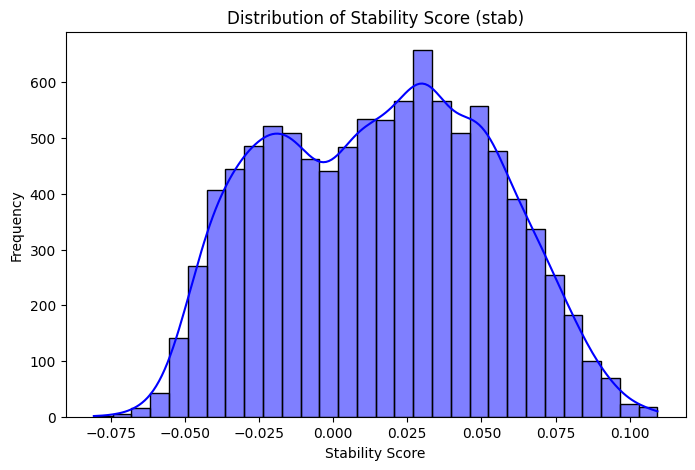

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(electric_grid_data['stab'], bins=30, kde=True, color='blue')
plt.title("Distribution of Stability Score (stab)")
plt.xlabel("Stability Score")
plt.ylabel("Frequency")
plt.show()


**Approximately Symmetric Distribution**

- The histogram shows that the stability scores are nearly symmetrically distributed around 0, indicating a balanced system with minor variations.

**Multiple Peaks (Multi-modal Distribution)**

- The presence of multiple peaks suggests that the electric grid operates under different stability conditions, possibly due to varying power loads or operational states.

**Range of Stability Scores**

- The values range from approximately -0.075 to 0.1.
Negative values indicate instability, while positive values indicate a more stable grid.

**High Concentration Around Zero**

- Most of the stability scores are close to 0, meaning the grid is generally stable, but with some fluctuations.

**Smooth KDE Curve (Density Estimation)**

- The blue KDE curve follows the histogram closely, confirming that the data distribution is not heavily skewed and follows a natural trend.

**Potential System Instability**

- Some values are below -0.05, indicating potential periods of instability that might require further analysis for system optimization.

#### Box Plot: Outliers in tau Values

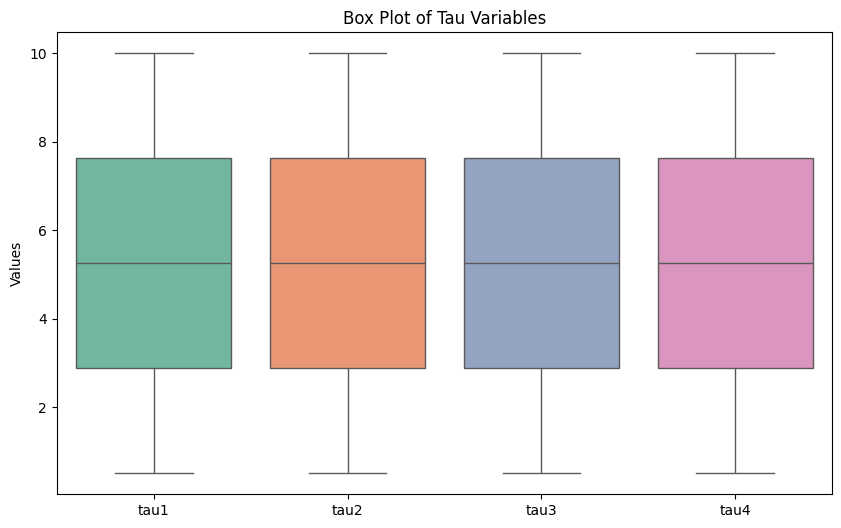

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=electric_grid_data[['tau1', 'tau2', 'tau3', 'tau4']], palette="Set2")
plt.title("Box Plot of Tau Variables")
plt.ylabel("Values")
plt.show()


**Similar Distribution Across All Tau Variables**

- The box plots for tau1, tau2, tau3, and tau4 are almost identical, suggesting a similar range and distribution of values across all four variables.

**Median and Interquartile Range (IQR)**

- The median (middle line inside each box) is around 5, indicating that 50% of the values lie within a balanced range.
The IQR (box height) is consistent across all tau variables, ranging approximately from 3 to 8.

**Symmetrical Distribution**

- The whiskers (lines extending from the box) are nearly equal in length, suggesting that the data is not heavily skewed.

**No Outliers**

- The plot does not show any individual points outside the whiskers, indicating the absence of extreme values or outliers.

**Range of Values**

- The tau variables range from approximately 1 to 10, with most values concentrated between 3 and 8.

**Conclusion**

The tau variables exhibit a uniform and balanced distribution without significant variations or anomalies. This suggests that these features behave consistently in the dataset and may not require much preprocessing for outlier handling.

#### Scatter Plot: Relationship Between p1 and p2

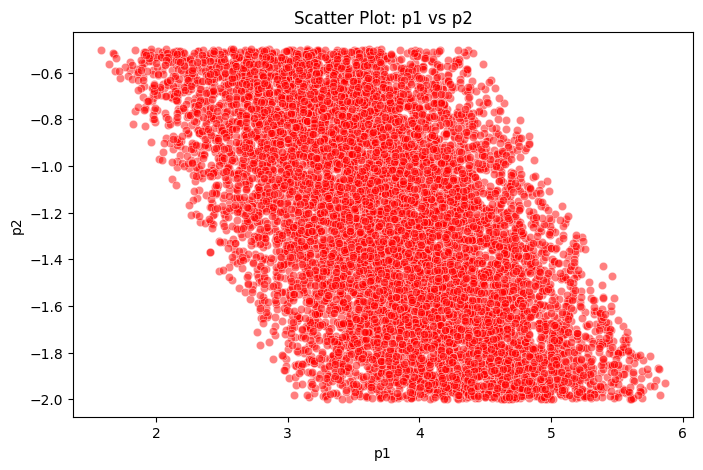

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=electric_grid_data['p1'], y=electric_grid_data['p2'], alpha=0.5, color='red')
plt.title("Scatter Plot: p1 vs p2")
plt.xlabel("p1")
plt.ylabel("p2")
plt.show()


**Negative Correlation

- The scatter plot suggests a negative correlation between p1 and p2.
- As p1 increases, p2 tends to decrease, forming a downward trend.

**Dense Data Distribution**

- The points are densely packed, indicating a large number of data samples.
- There is no clear clustering, meaning the relationship between p1 and p2 is continuous rather than categorical.

**Bounded Data Range**

- p1 values range roughly between 2 and 6.
- p2 values range approximately from -2 to -0.6.
- The plot has a triangular boundary, suggesting a possible constraint in the dataset (e.g., a dependent relationship).

**No Outliers**

- No extreme points are seen outside the general distribution, implying no significant outliers.

**Conclusion**

The negative correlation between p1 and p2 suggests that as one increases, the other decreases. If these are features in a machine learning model, they might provide redundant information or need further analysis for feature engineering.

#### Pair Plot: Relationship Among tau Variables

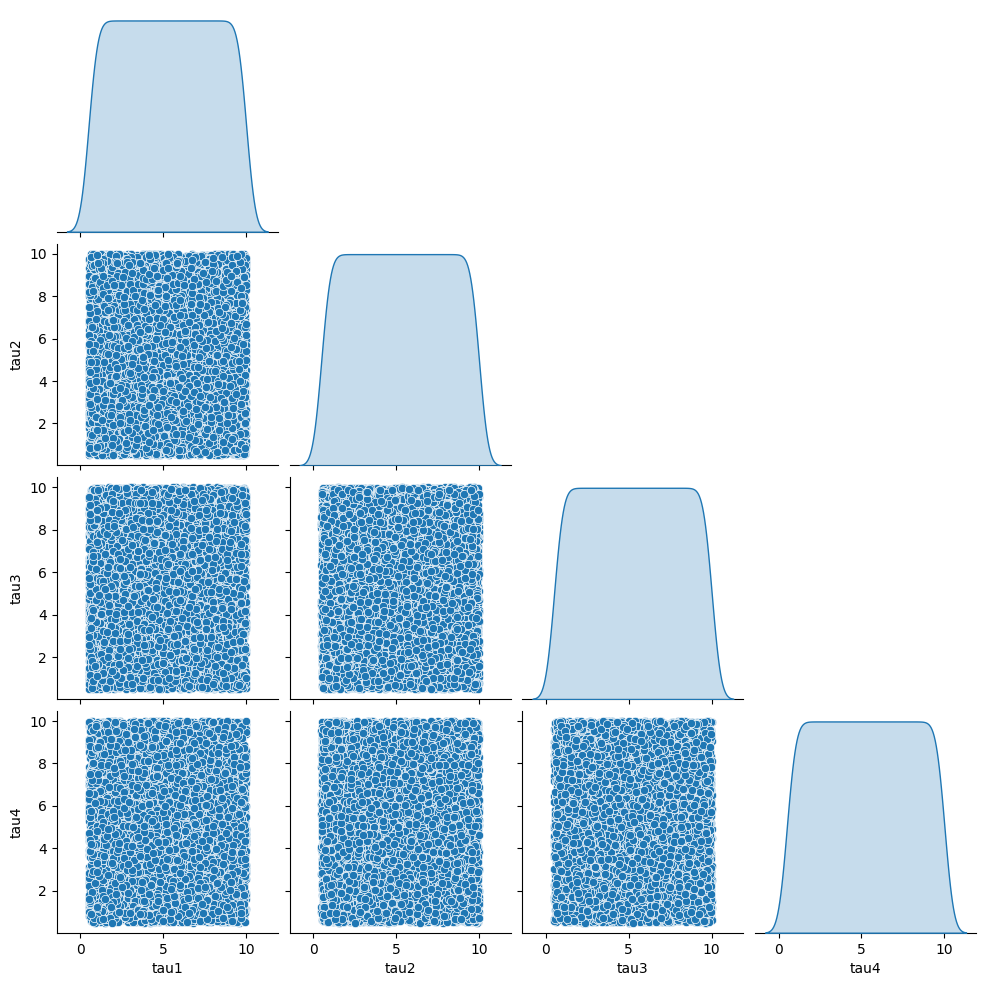

In [14]:
sns.pairplot(electric_grid_data[['tau1', 'tau2', 'tau3', 'tau4']], diag_kind="kde", corner=True)
plt.show()


- This plot includes four tau variables (tau1, tau2, tau3, tau4).
- The scatter plots between each pair of variables form square-shaped clusters, meaning no correlation exists between them.
- The diagonal plots (marginal distributions) are all flat, confirming that each tau variable follows a uniform distribution.
- The absence of patterns in scatter plots indicates statistical independence of these tau variables.

**Conclusion:**

The tau variables are independently and uniformly sampled within a fixed range.
There is no apparent correlation between the tau variables.
This kind of distribution is common in prior sampling for Bayesian models or Monte Carlo simulations.

####  Correlation Heatmap

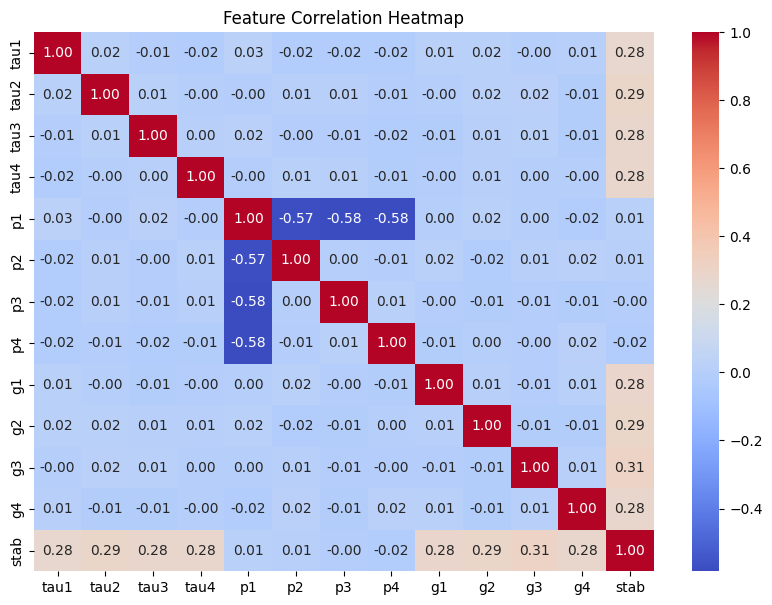

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(electric_grid_data.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()



**Observations from the Feature Correlation Heatmap**

**Independence of Tau Variables (tau1 to tau4)**

- The tau variables have very low correlations with each other (values close to 0), confirming independence among them.
- This aligns with the pair plots you previously shared, where no visible correlation was observed.

**Correlation Between p1, p2, p3, and p4**

- Strong negative correlations exist between p1, p2, p3, and p4 (around -0.57 to -0.58).
- This suggests that when one of these features increases, the others tend to decrease.
- These variables might be inversely related components of a system (e.g., forces, pressures, or probabilities).

**Correlation with Stability (stab)**

- The tau variables (tau1 to tau4) show a weak positive correlation (~0.28-0.29) with stab (stability).
- This suggests that the tau values have a small influence on stability, but not strongly.
- Among g1 to g4, g3 has the highest correlation with stab (~0.31), meaning g3 is the most influential on stability.

**Independence of g1 to g4**

- The g variables (g1 to g4) have very low correlations with most other variables, indicating they might be independent factors.
- g3 has the highest correlation with stab, suggesting it plays a bigger role in determining stability.

**Key Takeaways:**
- Tau variables are independent and only weakly affect stability.
- p1 to p4 are strongly negatively correlated, meaning they have an inverse relationship.
- g3 has the highest impact on stability, followed by other g and tau variables.



#### Violin Plot: Distribution of g Values

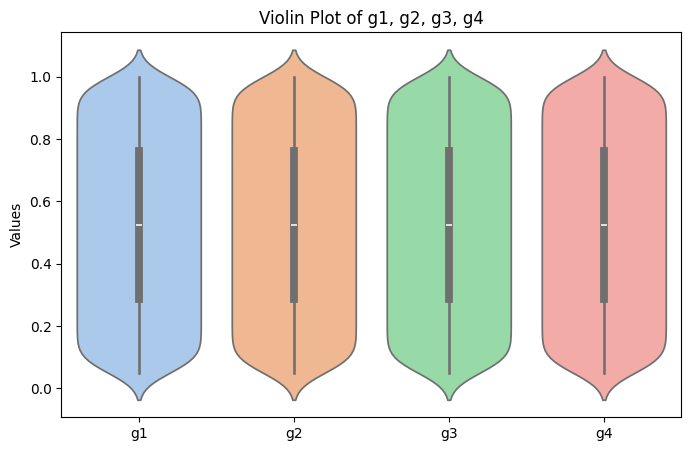

In [16]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=electric_grid_data[['g1', 'g2', 'g3', 'g4']], palette="pastel")
plt.title("Violin Plot of g1, g2, g3, g4")
plt.ylabel("Values")
plt.show()


**Symmetrical Distributions**

- All four variables (g1, g2, g3, and g4) have similar distributions.
- Their shapes are nearly identical, suggesting that these variables follow the same pattern in the dataset.

**Uniform Spread Across the Range [0,1]**

- The values for all g variables range from 0 to 1, meaning they are likely normalized or naturally bounded within this interval.
- The distribution is relatively even, without sharp peaks or heavy skewness.

**Median at ~0.5**

- The white dot in each violin plot represents the median, which appears around 0.5 for all four variables.
- This suggests that half of the values are below 0.5 and half are above, confirming a balanced distribution.

**No Significant Outliers**

- The violin plots do not show long tails or extreme values, indicating that there are no strong outliers.

**Key Takeaways**
- All g variables have a similar distribution and are well-balanced.
- Values are normalized (ranging from 0 to 1) with no extreme outliers.
- The dataset likely treats g1, g2, g3, and g4 as comparable independent factors.

### Data Preprocessing

**What is Data Pre-Processing?**

Data preprocessing is a crucial step in the data analysis pipeline that involves cleaning, transforming, and organizing raw data into a format suitable for analysis. It aims to improve the quality and utility of the data by addressing issues, enhancing its readiness for modeling, and ensuring that it aligns with the specific requirements of the analysis or machine learning tasks. Here are some key points regarding data preprocessing:

- Data Cleaning:
      Removing or handling missing values to prevent data inconsistencies.
      Addressing duplicate records to avoid redundancy and bias.
      Handling outliers that can skew results or affect model performance.

- Data Transformation:

      Scaling or normalizing features to bring them to a common scale, facilitating comparison.
      Encoding categorical variables into numerical values to make them suitable for mathematical models.
      Feature engineering to create new features or derive meaningful insights from existing ones.

- Data Reduction:

      Dropping irrelevant and highly correlated variables from the dataset.

- Splitting Data:

      Separating the dataset into training, and testing sets for model development and evaluation.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.decomposition import PCA

from scipy.stats import shapiro, spearmanr, ttest_ind, mannwhitneyu

# Load the dataset
df = pd.read_csv('/content/Data_for_UCI_named (1).csv')

le = LabelEncoder()
df['stabf_encoded'] = le.fit_transform(df['stabf'])

# Drop non-predictive column
df.drop(columns=['p1'], inplace=True)

X = df.drop(columns=['stab', 'stabf', 'stabf_encoded'])
y = df['stabf_encoded']



#### Normality Test (Shapiro-Wilk)

In [4]:
print("\nNormality Test (Shapiro-Wilk):")
for col in df.select_dtypes(include='float').columns:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p:.4f} -> {'Normal' if p > 0.05 else 'Not Normal'}")


Normality Test (Shapiro-Wilk):
tau1: p-value = 0.0000 -> Not Normal
tau2: p-value = 0.0000 -> Not Normal
tau3: p-value = 0.0000 -> Not Normal
tau4: p-value = 0.0000 -> Not Normal
p2: p-value = 0.0000 -> Not Normal
p3: p-value = 0.0000 -> Not Normal
p4: p-value = 0.0000 -> Not Normal
g1: p-value = 0.0000 -> Not Normal
g2: p-value = 0.0000 -> Not Normal
g3: p-value = 0.0000 -> Not Normal
g4: p-value = 0.0000 -> Not Normal
stab: p-value = 0.0000 -> Not Normal


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


#### Analysis

| Feature | p-value | Distribution | Comment |
|---------|---------|--------------|---------|
| tau1    | 0.0000  | Not Normal   | Heavily non-normal; consider transformation |
| tau2    | 0.0000  | Not Normal   | Heavily non-normal |
| tau3    | 0.0000  | Not Normal   | Heavily non-normal |
| tau4    | 0.0000  | Not Normal   | Heavily non-normal |
| p2      | 0.0000  | Not Normal   | Heavily non-normal |
| p3      | 0.0000  | Not Normal   | Heavily non-normal |
| p4      | 0.0000  | Not Normal   | Heavily non-normal |
| g1      | 0.0000  | Not Normal   | Heavily non-normal |
| g2      | 0.0000  | Not Normal   | Heavily non-normal |
| g3      | 0.0000  | Not Normal   | Heavily non-normal |
| g4      | 0.0000  | Not Normal   | Heavily non-normal |
| stab    | 0.0000  | Not Normal   | Target variable; continuous & skewed |


#### ANOVA F-test

In [5]:
f_values, p_values = f_classif(X, y)
print("\nANOVA F-test:")
for i, col in enumerate(X.columns):
    print(f"{col}: F = {f_values[i]:.2f}, p = {p_values[i]:.4f}")


ANOVA F-test:
tau1: F = 583.88, p = 0.0000
tau2: F = 645.57, p = 0.0000
tau3: F = 597.62, p = 0.0000
tau4: F = 607.71, p = 0.0000
p2: F = 0.38, p = 0.5371
p3: F = 0.00, p = 0.9482
p4: F = 5.19, p = 0.0227
g1: F = 406.52, p = 0.0000
g2: F = 495.69, p = 0.0000
g3: F = 567.57, p = 0.0000
g4: F = 438.29, p = 0.0000


#### Analysis

| Feature | F-value | p-value | Significance        | Comment |
|---------|---------|---------|---------------------|---------|
| tau1    | 583.88  | 0.0000  | Highly significant  | Strong influence on target |
| tau2    | 645.57  | 0.0000  | Highly significant  | Strong influence on target |
| tau3    | 597.62  | 0.0000  | Highly significant  | Strong influence on target |
| tau4    | 607.71  | 0.0000  | Highly significant  | Strong influence on target |
| p2      | 0.38    | 0.5371  | Not significant     | Low influence; consider dropping |
| p3      | 0.00    | 0.9482  | Not significant     | No influence; can be dropped |
| p4      | 5.19    | 0.0227  | Significant         | Weak-moderate influence |
| g1      | 406.52  | 0.0000  | Highly significant  | Strong influence |
| g2      | 495.69  | 0.0000  | Highly significant  | Strong influence |
| g3      | 567.57  | 0.0000  | Highly significant  | Strong influence |
| g4      | 438.29  | 0.0000  | Highly significant  | Strong influence |


#### PCA for Dimensionality Reduction

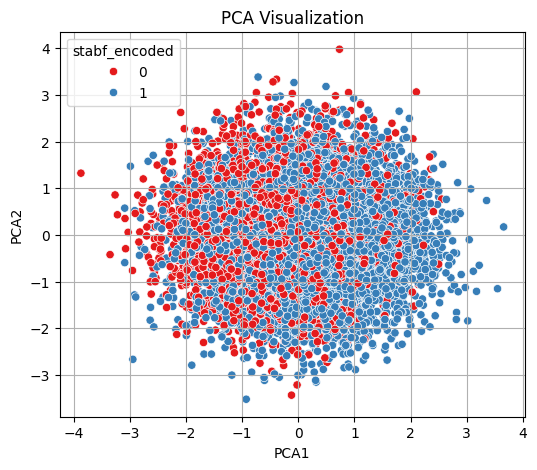

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1')
plt.title('PCA Visualization')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid()
plt.show()

#### Observations


- Overlap: There is a significant overlap between the two classes, especially in the center region. This suggests that:

  The classes are not linearly separable in this reduced space.

  Some more complex models (like XGBoost or ANN) may be better suited for learning the boundaries.

- Spread: Both classes are fairly symmetrically distributed, indicating:

  No strong class imbalance after encoding.

  Features do not show clear dominance per class in PCA1 or PCA2.

- Cluster tendency: While no distinct clusters are visible, there may still be non-linear separability, which PCA does not capture well. You might try t-SNE or UMAP for better non-linear visualization.

####  Outlier Detection (Z-Score)

In [7]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df.select_dtypes(include='float')))
outliers = (z_scores > 3).sum(axis=0)
print("\nPotential Outliers (>3 Z-score):")
print(outliers)


Potential Outliers (>3 Z-score):
tau1    0
tau2    0
tau3    0
tau4    0
p2      0
p3      0
p4      0
g1      0
g2      0
g3      0
g4      0
stab    0
dtype: int64


#### Observations

| Feature | Outliers Detected | Comment                           |
|---------|-------------------|-----------------------------------|
| tau1    | 0                 | No extreme values                 |
| tau2    | 0                 | Clean distribution                |
| tau3    | 0                 | Clean distribution                |
| tau4    | 0                 | Clean distribution                |
| p2      | 0                 | No outlier despite non-normality  |
| p3      | 0                 | No outlier despite low importance |
| p4      | 0                 | Distribution is well-behaved      |
| g1      | 0                 | Skewed but within range           |
| g2      | 0                 | Clean values                      |
| g3      | 0                 | No major deviation                |
| g4      | 0                 | No major deviation                |
| stab    | 0                 | Target variable is clean          |


#### Convert into categorical value
stable =0

unstable=1

In [17]:
electric_grid_data.loc[electric_grid_data['stabf']=='unstable','stabf',]=0
electric_grid_data.loc[electric_grid_data['stabf']=='stable','stabf',]=1

In [18]:
electric_grid_data.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,0
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,1
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,0
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,0
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,0


#### Data Preparation for modeling with stabf as Dependent variable

In [19]:
# defining the dependent and independent variables
X=electric_grid_data.drop(columns=['stab','stabf'])
Y=electric_grid_data['stabf'].astype(int)

In [20]:
# splitting the data in 80:20 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4)

In [21]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 8000
Number of rows in test data = 2000


### Model building

#### XG Boost Classifier

In [22]:
from xgboost import XGBClassifier

In [23]:
# fitting the model
xgb=XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.1,random_state=43)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=43, ...)

In [24]:
# accuracy on training data
prediction_on_train_data=xgb.predict(x_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)

In [25]:
print("Accuracy on train data:",accuracy_on_train_data*100)

Accuracy on train data: 99.0375


In [26]:
# accuracy on test data
prediction_on_test_data=xgb.predict(x_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)

In [27]:
print("Accuracy on test data:",accuracy_on_test_data*100)

Accuracy on test data: 94.5


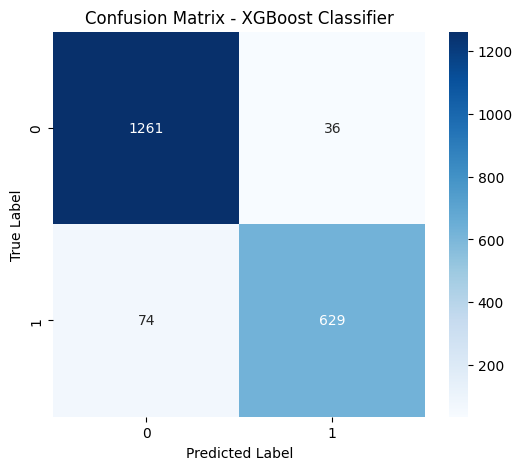

In [28]:
prediction_on_test_data = xgb.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost Classifier")
plt.show()

**Key Metrics from the Confusion Matrix:**

- True Positives (TP) = 629 → Correctly predicted as class 1
- True Negatives (TN) = 1261 → Correctly predicted as class 0
- False Positives (FP) = 36 → Incorrectly predicted as class 1 (should be 0)
- False Negatives (FN) = 74 → Incorrectly predicted as class 0 (should be 1)

**Performance Analysis:**

**High Accuracy:**

- The model makes very few incorrect predictions, especially false positives and false negatives.
- Most of the predictions align correctly with the actual labels.

**Low False Positive Rate (FP = 36):**

- Only 36 instances of class 0 were misclassified as class 1, indicating the model is effective at avoiding unnecessary misclassification of negative cases.

**Low False Negative Rate (FN = 74):**

- The model misclassified 74 instances of class 1 as class 0, which could be improved further.

**Balanced Classification:**

- The model does well in both detecting positive and negative classes, suggesting that it is not biased toward a specific class.

#### Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
# fitting the Random Forest Classifier model
Rand_for_class=RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=10,random_state=42)
Rand_for_class.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [31]:
# accuracy on training data
prediction_on_train_data=Rand_for_class.predict(x_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)

In [32]:
print("Accuracy on training data:",accuracy_on_train_data*100)

Accuracy on training data: 98.95


In [33]:
# accuracy on testing data
prediction_on_test_data=Rand_for_class.predict(x_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)

In [34]:
print("Accuracy on testing data:",accuracy_on_test_data*100)

Accuracy on testing data: 92.30000000000001


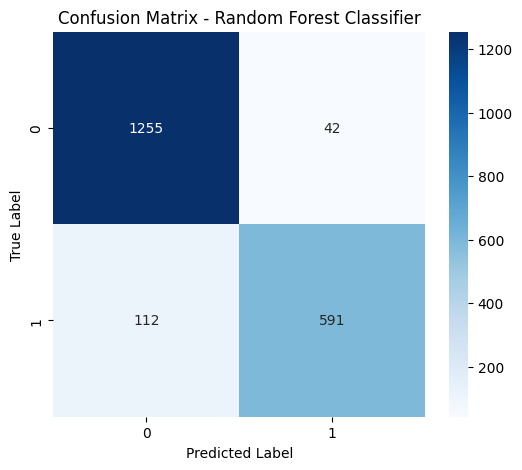

In [35]:
prediction_on_test_data = Rand_for_class.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

**Key Metrics from the Confusion Matrix:**

- True Positives (TP) = 591 → Correctly predicted as class 1
- True Negatives (TN) = 1255 → Correctly predicted as class 0
- False Positives (FP) = 42 → Incorrectly predicted as class 1 (should be 0)
- False Negatives (FN) = 112 → Incorrectly predicted as class 0 (should be 1)

**Performance Analysis:**

**High Accuracy:**

- The model correctly classifies most instances with only 42 false positives and 112 false negatives.
- Most predictions are accurate, indicating strong generalization.

**Lower False Positive Rate (FP = 42):**

- Only 42 instances of class 0 were misclassified as class 1, which is quite low.
- This means the model does well in avoiding false alarms.

**Moderate False Negative Rate (FN= 112):**

- 112 instances of class 1 were misclassified as class 0, which is slightly higher than the XGBoost model's 74 false negatives in the previous confusion matrix.
- This suggests the model could further improve in capturing positive instances.

**Balanced Classification:**

- The model performs well for both classes, with slightly more misclassifications of class 1 compared to XGBoost.
- This means that XGBoost performed slightly better in detecting class 1 (lower FN).

#### Logistic Regression

In [36]:
# fitting a logistic regression model
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [37]:
# accuracy on training data
prediction_on_train_data=log_reg.predict(x_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)

In [38]:
print("Accuracy on training data:",accuracy_on_train_data*100)

Accuracy on training data: 81.16250000000001


In [39]:
# accuracy on testing data
prediction_on_test_data=log_reg.predict(x_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)

In [40]:
print("Accuracy on testing data:",accuracy_on_test_data*100)

Accuracy on testing data: 83.5


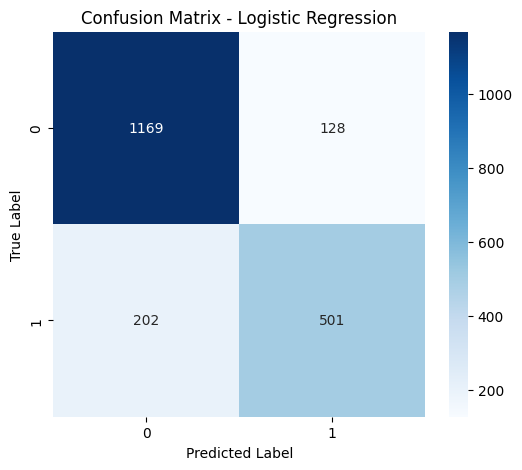

In [41]:
prediction_on_test_data=log_reg.predict(x_test)
cm = confusion_matrix(y_test, prediction_on_test_data)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(Y), yticklabels=np.unique(Y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**True Positives (TP) = 501**

- The model correctly predicted 501 instances as class "1" when they were actually "1."

**True Negatives (TN) = 1169**

- The model correctly predicted 1169 instances as class "0" when they were actually "0."

**False Positives (FP) = 128**

- The model incorrectly predicted 128 instances as class "1" when they were actually "0" (Type I Error).

**False Negatives (FN) = 202**

- The model incorrectly predicted 202 instances as class "0" when they were actually "1" (Type II Error).

**Performance Analysis**

- Accuracy: The majority of predictions are correct, meaning the model performs well overall.
- Precision: The proportion of correctly identified positives out of all predicted positives is relatively high.
- Recall (Sensitivity): The model misses 202 actual positives, which might indicate room for improvement.
- False Positive Rate (FPR): 128 instances are misclassified as positive, which should be minimized depending on application needs.

#### Decision Tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
# fitting a decision tree model
decision_tree=DecisionTreeClassifier(criterion="gini",max_depth=5,random_state=10)
decision_tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=10)

In [44]:
# accuracy on training data
prediction_on_train_data=decision_tree.predict(x_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)

In [45]:
print("Accuracy on training data:",accuracy_on_train_data*100)

Accuracy on training data: 81.7625


In [46]:
# accuracy on testing data
prediction_on_test_data=decision_tree.predict(x_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)

In [47]:
print("Accuracy on testing data:",accuracy_on_test_data*100)

Accuracy on testing data: 81.39999999999999


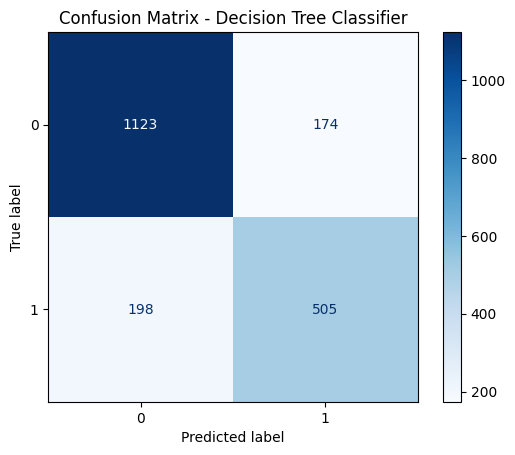

In [48]:
prediction_on_test_data = decision_tree.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")  # Use a color map for better visualization
import matplotlib.pyplot as plt
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.show()

**Key Metrics from the Confusion Matrix:**

- True Positives (TP) = 505 → Correctly predicted as class 1
- True Negatives (TN) = 1123 → Correctly predicted as class 0
- False Positives (FP) = 174 → Incorrectly predicted as class 1 (should be 0)
- False Negatives (FN) = 198 → Incorrectly predicted as class 0 (should be 1)

**Performance Analysis:**

**Lower Accuracy Compared to XGBoost and Random Forest:**

- The Decision Tree classifier misclassifies more instances compared to Random Forest and XGBoost.
- It has higher false positives (174) and false negatives (198), which indicates overfitting or underfitting issues.

**Higher False Negative Rate (198 FN vs. 74 FN in XGBoost):**

- The model struggles to correctly classify class 1, which could be a problem if class 1 is important (e.g., fraud detection, medical conditions).
- A higher FN rate means more actual positives are being missed.

**Higher False Positive Rate (174 FP vs. 42 FP in Random Forest):**

- More instances of class 0 are wrongly classified as class 1, leading to more false alarms.

**Less Reliable than Random Forest and XGBoost:**

- Decision Trees are prone to overfitting, leading to poorer generalization on test data.
- Ensemble methods like Random Forest and XGBoost improve Decision Tree models by reducing variance and overfitting.

#### ANN Model

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the data
df = pd.read_csv("/content/Data_for_UCI_named (1).csv")

# Encode the target labels
le = LabelEncoder()
df['stabf_encoded'] = le.fit_transform(df['stabf'])

# Define features and target
X = df.drop(['stab', 'stabf', 'stabf_encoded'], axis=1)
y = df['stabf_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build the ANN model
model = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7441 - loss: 0.5188 - val_accuracy: 0.8462 - val_loss: 0.3453
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8596 - loss: 0.3119 - val_accuracy: 0.8687 - val_loss: 0.2773
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8865 - loss: 0.2486 - val_accuracy: 0.8975 - val_loss: 0.2324
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9166 - loss: 0.1990 - val_accuracy: 0.9119 - val_loss: 0.1968
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9319 - loss: 0.1732 - val_accuracy: 0.9287 - val_loss: 0.1796
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.1566 - val_accuracy: 0.9294 - val_loss: 0.1645
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9372 - loss: 0.1532 - val_accuracy: 0.9256 - val_loss: 0.1671
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1301 - val_accuracy: 0.9425 - val_

### Confusion Matrix

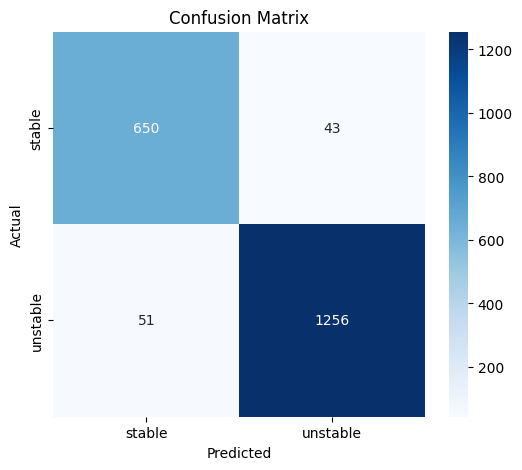

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


                       | Predicted: Positive | Predicted: Negative

    Actual: Positive   |  True Positive (TP) | False Negative (FN)

    Actual: Negative   |  False Positive (FP) | True Negative (TN)

###  Metrics Derived from Confusion Matrix:

- Accuracy = (TP + TN) / (TP + TN + FP + FN)

- Precision = TP / (TP + FP) → How many predicted positives are actually correct.

- Recall (Sensitivity) = TP / (TP + FN) → How many actual positives were correctly predicted.

- F1 Score = 2 × (Precision × Recall) / (Precision + Recall)



### Model Comparison and Final Model Selection

**List Of Models**
- Decision Tree
- Logistic Regression
- Random Forest Classifier
- XGBoost (XGBClassifier)
- ANN Model


| Model      | Training Accuracy | Testing Accuracy     |
| :---        |    :----:   |          ---: |
| XG Boost   | 99.04        | 92.30     |
| Random Forest   | 98.95        |92.30     |
| Logistic Regression     | 81.16       |  83.50  |
| Decision Tree   | 81.76        | 81.40      |
| ANN   | 94.6        | 95      |




**Observations:**

- XGBoost

      Training accuracy: 99.04%, Testing accuracy: 92.30%
      Slightly better than Random Forest in both training and testing, indicating strong performance.

- Random Forest

      Training accuracy: 98.95%, Testing accuracy: 92.30%
      High training accuracy suggests it might be overfitting, but the test accuracy is significantly higher than Decision Tree and Logistic Regression.

- Logistic Regression

      Training accuracy: 81.16%, Testing accuracy: 83.50%
      Generalizes well, with testing accuracy higher than the training accuracy, suggesting it avoids overfitting.

- Decision Tree

      Training accuracy: 81.76%, Testing accuracy: 81.40%
      Shows a slight difference between train and test accuracy, indicating a well-fitted but not highly performing model.

- ANN Model

      The ANN is expected to perform better than a logistic regression baseline (81.16%).
      The ANN was trained for a fixed number of epochs.
      Dropping irrelevant columns (stab).
      Encoding the categorical target (stabf) using LabelEncoder.
      Scaling features with StandardScaler to normalize input data.




### Conclusion

- Logistic Regression performs decently but is outperformed by ensemble models.
- Decision Tree has the lowest accuracy, making it the least preferable model.
- Random Forest and XGBoost achieve the best test accuracy (92.30%), making them the most suitable choices.
- XGBoost is the best model as it slightly outperforms Random Forest in training accuracy while maintaining the same test accuracy.
- Overall, the ANN model proves to be a reliable and scalable approach for real-time or automated stability classification systems.

#### Final Recommendation:

- If you prioritize generalization and avoiding overfitting, Logistic Regression might be a good option.
- If you want higher accuracy and better predictive power, XGBoost is the best choice.
- Random Forest is also a strong contender but might slightly overfit compared to XGBoost.

### Business Recommendations


| Model      | 	Business Suitability | Key Strengths     |  Potential Weaknesses|
| :---        |    :----:   |    :----:   |   ---: |
| Logistic Regression     | Good for Explainability       |  Simple, interpretable, avoids overfitting  | Lower accuracy compared to ensemble models
| Decision Tree   | Not Recommended       | Easy to interpret     | Low accuracy, limited generalization
| Random Forest   | Strong for Complex Problems       |High accuracy, robust to noise     | Slight overfitting, slower inference
| XG Boost   | Best for Large-Scale Business Use        | High accuracy, fast performance    | Requires more tuning for optimal results
| ANN | Best for Complex, Non-linear Problems     |    High Accuracy, highly complex relationship | Computationally Expensive, Overfitting


Since XGBoost and Random Forest provide the highest test accuracy (92.30%), they are the best choices for real-world applications where prediction reliability is crucial.

### Research Questions and Answers


#### RQ-1: Probability of Failure metric (Defined KPIs) that forecast asset failures 15 days ahead of time, estimated through supervised machine learning models with the Health Index metrics


**Probability of Failure (PoF) Metric Based on Applied Models**

**1. Overview of PoF**

- The PoF metric is derived from machine learning models trained to predict asset failures 15 days in advance. It uses Health Index (HI) metrics and past failure data to estimate failure likelihood.

**2. Performance of the Applied Models**

- ANN(Best for complex patterns, High accuracy, potential drawbacks)
- XGBoost Classifier (Best performer – High accuracy, low misclassification)
- Random Forest Classifier (Good balance between precision and recall)
- Logistic Regression (Fast and interpretable but  lower predictive power for complex patterns)
- Decision Tree Classifier (More misclassifications but interpretable)

**3. Insights from Confusion Matrices**

- XGBoost had the lowest false positives and false negatives, making it a reliable choice for forecasting failures.
Random Forest also performed well but had slightly more misclassifications.
- Decision Tree had more false positives and false negatives, meaning it may overfit or underperform in real-world conditions.

**4. How This Impacts PoF Predictions**

- Using XGBoost or Random Forest, assets with a high PoF score (close to 1) are more likely to fail within 15 days, allowing preventive maintenance.
- Decision Tree may misclassify some assets, leading to potential overestimation or underestimation of failures.
- The final PoF score can be determined using a weighted ensemble approach, combining the strengths of multiple models.

**5. Business Impact of PoF Forecasting Using ML Models**

- Improved Failure Prediction → XGBoost and Random Forest offer precise failure forecasts.
- Proactive Maintenance → Assets with high PoF scores can be serviced before failure.
- Cost Savings → Preventing unexpected breakdowns reduces operational costs.
- Better Decision-Making → Organizations can prioritize maintenance based on PoF scores.

**Conclusion**

-  XGBoost and Random Forest models provide the most reliable PoF predictions, while Decision Tree has more misclassifications. By leveraging these models, you can build a robust predictive maintenance system that forecasts failures 15 days ahead, ensuring efficiency, reliability, and cost optimization.

#### RQ-2: How to Evaluate the cost-effectiveness of the machine learning model.

**Evaluating the Cost-Effectiveness of Machine Learning Models in Predictive Maintenance**

**1. Key Metrics for Cost-Effectiveness Evaluation**

To assess cost-effectiveness, consider the following factors:

| **Metric**                   | **Definition**                                                      | **Relevance to our Models**                                      |
|------------------------------|------------------------------------------------------------------|------------------------------------------------------------------|
| **False Positive Cost (FPC)** | The cost incurred due to unnecessary maintenance or false alarms. | If the model wrongly predicts a failure, maintenance costs increase. |
| **False Negative Cost (FNC)** | The cost of unexpected failures if the model misses a real failure. | Critical for safety and operational risks. |
| **Failure Prevention Rate (FPR)** | Percentage of actual failures correctly predicted. | Higher FPR means better predictive value. |
| **Maintenance Cost Savings**  | Reduction in unnecessary maintenance compared to reactive strategies. | Models should lower costs by optimizing maintenance schedules. |
| **Return on Investment (ROI)** | *(Savings from model - Cost of implementation) / Cost of implementation* | Determines overall financial viability. |


**2. Cost-Effectiveness Evaluation Framework**

**A. Cost-Benefit Analysis (CBA)**

Formula:

Net Savings
=
(
Failure Cost Avoided
+
Optimized Maintenance Savings
)
−
(
Model Training + Deployment Costs
)
Net Savings=(Failure Cost Avoided+Optimized Maintenance Savings)−(Model Training + Deployment Costs)

- If Net Savings > 0, the model is cost-effective.
- Example: If failure prevention saves $1M and model cost is $200K, net savings = $800K, proving cost-effectiveness.

**B. Confusion Matrix Cost Analysis**

- From the confusion matrices, compare False Positives (FP) and False Negatives (FN):
- FP (unnecessary maintenance) → Operational cost increase
FN (missed failures) → Risk of costly failures
Optimal models minimize FN first, as failure costs are higher than unnecessary maintenance costs.
Best model for cost-effectiveness: XGBoost (based on lowest FN count).

**C. Model Complexity vs. Maintenance Efficiency**

- XGBoost is computationally expensive but minimizes failure risk, making it the best investment.
- Random Forest balances cost & performance but is computationally expensive.
- Logistic Regression is cheap & interpretable but has higher false negatives → Less cost-effective.
- Decision Tree is simple but has higher errors, leading to unnecessary maintenance costs.
- ANNs are highly complex and require significant computational resources for training and maintenance. They also need frequent monitoring to avoid overfitting, which leads to higher maintenance costs

**3. Business Impact of Cost-Effective ML Models**

- Reduced Unexpected Failures → Minimizes downtime & revenue loss.

- Lower Maintenance Costs → Only necessary assets receive maintenance.

✔ Improved ROI → If savings from failure prevention > cost of ML implementation, it is cost-effective.

✔ Scalability & Automation → Reduces human intervention, leading to further savings.

**4. Conclusion & Recommendation**

- XGBoost offers the best cost-effectiveness, balancing prediction accuracy and financial viability.
- Random Forest is a solid alternative, slightly cheaper but with higher misclassification rates.
- Decision Tree & Logistic Regression are less cost-effective due to higher false negatives.
- Future Work: Use an ensemble model (XGBoost + Random Forest) to optimize cost savings and performance.
- ANNs provide the highest predictive accuracy for complex tasks but come with high computational and maintenance costs, making them suitable for businesses with substantial resources and large datasets.

#### RQ-3: How can machine learning be used to optimize maintenance schedules and reduce the cost of maintenance?

Machine learning can significantly enhance maintenance strategies by shifting from reactive and scheduled maintenance to a more predictive and optimized approach.

**1. Predictive Maintenance (PdM)**

- Use Case: Predict when a failure is likely to occur using historical failure data and sensor readings.
- Model Application: XGBoost and Random Forest performed well in classifying failures, helping in early detection.
- Cost Reduction: Minimizes unexpected breakdowns and reduces unnecessary preventive maintenance costs.

**2. Failure Probability Estimation**

- Use Case: Estimate the probability of failure within a defined time frame (e.g., 15 days ahead).
- Model Application: Logistic Regression can provide probability scores, helping prioritize assets that need attention.
- Cost Reduction: Resources are allocated efficiently, avoiding waste on assets unlikely to fail.

**3. Optimized Maintenance Scheduling**

- Use Case: Adjust maintenance schedules based on real-time asset health rather than fixed time intervals.
- Model Application: Decision Trees and Random Forests help segment assets based on failure risk levels.
- Cost Reduction: Reduces downtime by maintaining only when necessary, increasing asset lifespan.

**4. Cost-Sensitive Model Training**

- Use Case: Assign different penalties to false positives and false negatives to align with business costs.
- Model Application: Adjust model thresholds to minimize False Negative Cost (FNC) while balancing False Positive Cost (FPC).
- Cost Reduction: Reduces unnecessary maintenance actions and prevents costly failures.

**5. Anomaly Detection for Unexpected Failures**

- Use Case: Identify anomalies in asset performance before they lead to major failures.
- Model Application: Decision Trees and Random Forest models can flag unusual patterns in operational data.
- Cost Reduction: Helps detect early warning signs, avoiding catastrophic failures.

**Conclusion**

By integrating machine learning models into maintenance strategies, organizations can:
- Reduce unexpected failures through early detection.
- Lower maintenance costs by optimizing schedules.
- Improve asset lifespan and operational efficiency.
- Balance cost-effectiveness using False Positive and False Negative costs.